Matriz U (vectores singulares izquierdos):
[[-0.10823953 -0.0409958   0.02721865  0.01371065]
 [-0.09945776  0.05757315  0.0500034   0.05843586]
 [-0.1129963   0.02920003 -0.00942089  0.01609833]
 [-0.1098971   0.05101939 -0.01945713 -0.03741666]
 [-0.11422046 -0.0552418  -0.00335436 -0.02037905]
 [-0.099203   -0.12718049 -0.00574789  0.00374883]
 [-0.11681027 -0.00406897 -0.07150054 -0.02086281]
 [-0.10671702 -0.01905755  0.01890413 -0.01396247]
 [-0.11158214  0.09525253 -0.03092098 -0.01523727]
 [-0.10439809  0.04005525  0.05408637 -0.02263491]
 [-0.10353694 -0.0891345   0.0572654   0.00949172]
 [-0.11117543 -0.01136531 -0.01998339 -0.07572529]
 [-0.10602896  0.06223126  0.04921531  0.00137573]
 [-0.12584679  0.08211573 -0.03853401 -0.01090099]
 [-0.10508692 -0.15885479  0.10079184  0.11047154]
 [-0.10812061 -0.22941723 -0.00650629  0.02866784]
 [-0.10550976 -0.12670495  0.00113901  0.10711633]
 [-0.10468588 -0.04174835  0.00942384  0.05281031]
 [-0.09074062 -0.11999307  0.07978572  

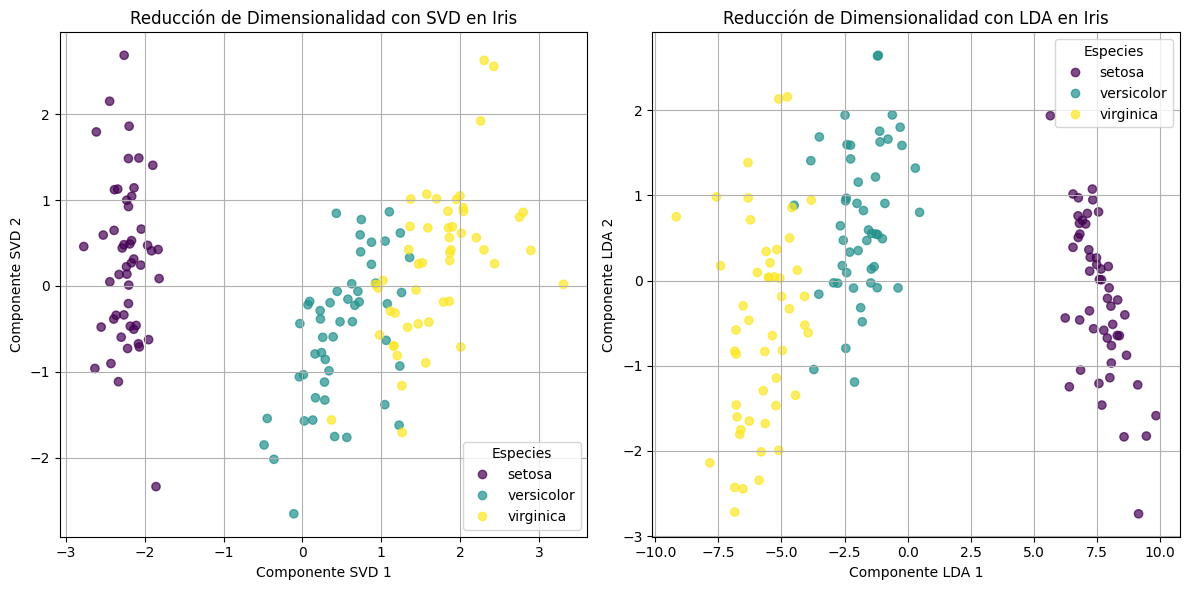

La especie predicha con k-NN (LDA) es: setosa
La especie predicha con SVM (LDA) es: setosa


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. Cargar el conjunto de datos Iris
iris = load_iris()
X = iris.data  # Matriz de características (4 dimensiones)
y = iris.target  # Etiquetas (3 clases de flores)

# 2. Normalizar los datos para que todas las características tengan la misma escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar SVD completo
U, Sigma, VT = np.linalg.svd(X_scaled, full_matrices=False)

# 4. Imprimir las matrices SVD
print("Matriz U (vectores singulares izquierdos):")
print(U)
print("\nMatriz Σ (valores singulares en diagonal):")
print(np.diag(Sigma))  # Convertimos la lista de valores en una matriz diagonal
print("\nMatriz V^T (vectores singulares derechos, transpuestos):")
print(VT)

# 5. Reducir a 2 dimensiones usando SVD truncado
svd = TruncatedSVD(n_components=2)
X_reduced_svd = svd.fit_transform(X_scaled)
# Esta última instrucción es equivalente a
#svd.fit(X_scaled)  # Calcula las matrices U, Σ y V^T
#X_reduced_svd = svd.transform(X_scaled)  # Proyecta los datos en el nuevo espacio de menor dimensión


# 6. Graficar los datos en el nuevo espacio 2D (SVD)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
scatter_svd = plt.scatter(X_reduced_svd[:, 0], X_reduced_svd[:, 1], c=y, cmap='viridis', alpha=0.7)

# Obtener los identificadores de los colores en la gráfica
handles_svd, _ = scatter_svd.legend_elements()

# Añadir etiquetas manualmente
plt.xlabel("Componente SVD 1")
plt.ylabel("Componente SVD 2")
plt.title("Reducción de Dimensionalidad con SVD en Iris")
plt.legend(handles=handles_svd, labels=list(iris.target_names), title="Especies")
plt.grid(True)

###################

from sklearn.neighbors import KNeighborsClassifier

# 7. Entrenar un modelo k-NN en el espacio reducido (SVD)
knn_svd = KNeighborsClassifier(n_neighbors=5)
#K-Nearest Neighbors (k-NN) es un algoritmo de aprendizaje supervisado que clasifica una nueva muestra comparándola con sus vecinos más cercanos en el espacio de características.
knn_svd.fit(X_reduced_svd, y)  # X_reduced_svd son los datos transformados por SVD

# 8. Nueva flor (ejemplo: sépalo largo=5.1,  sépalo ancho=3.5, pétalo largo =1.4, etc.)
nueva_flor = np.array([[5.1, 3.5, 1.4, 0.2]])  # Dimensiones de la nueva flor
#nueva_flor = np.array([[6.0, 3.0, 4.8, 1.8]])  # Sé libre de cambiar estos valores

# 9. Aplicar la misma normalización y transformación SVD
nueva_flor_scaled = scaler.transform(nueva_flor)
nueva_flor_reduced_svd = svd.transform(nueva_flor_scaled)

# 10. Predecir la especie (k-NN con SVD)
prediccion_knn_svd = knn_svd.predict(nueva_flor_reduced_svd)
print("La especie predicha con k-NN (SVD) es:", iris.target_names[prediccion_knn_svd[0]])

################ ALTERNATIVAMENTE

from sklearn.svm import SVC

# Entrenar SVM en el espacio original
svm = SVC(kernel='linear')
svm.fit(X_scaled, y)

# Predecir la especie de la nueva flor (SVM en espacio original)
prediccion_svm = svm.predict(nueva_flor_scaled)
print("La especie predicha con SVM (espacio original) es:", iris.target_names[prediccion_svm[0]])

################ ALTERNATIVAMENTE - USO DE LDA ################

print("\n--- Análisis con Linear Discriminant Analysis (LDA) ---")

# Inicializar y ajustar LDA para reducir a 2 componentes para visualización
lda = LinearDiscriminantAnalysis(n_components=2)
X_reduced_lda = lda.fit_transform(X_scaled, y)

# Graficar los datos en el nuevo espacio 2D (LDA)
plt.subplot(1, 2, 2)
scatter_lda = plt.scatter(X_reduced_lda[:, 0], X_reduced_lda[:, 1], c=y, cmap='viridis', alpha=0.7)

# Obtener los identificadores de los colores en la gráfica
handles_lda, _ = scatter_lda.legend_elements()

# Añadir etiquetas manualmente
plt.xlabel("Componente LDA 1")
plt.ylabel("Componente LDA 2")
plt.title("Reducción de Dimensionalidad con LDA en Iris")
plt.legend(handles=handles_lda, labels=list(iris.target_names), title="Especies")
plt.grid(True)

plt.tight_layout()
plt.show()

# Entrenar un modelo k-NN en el espacio reducido por LDA
knn_lda = KNeighborsClassifier(n_neighbors=5)
knn_lda.fit(X_reduced_lda, y)

# Aplicar la misma transformación LDA a la nueva flor
nueva_flor_reduced_lda = lda.transform(scaler.transform(nueva_flor))

# Predecir la especie (k-NN con LDA)
prediccion_knn_lda = knn_lda.predict(nueva_flor_reduced_lda)
print("La especie predicha con k-NN (LDA) es:", iris.target_names[prediccion_knn_lda[0]])

# Entrenar SVM en el espacio reducido por LDA
svm_lda = SVC(kernel='linear')
svm_lda.fit(X_reduced_lda, y)

# Predecir la especie de la nueva flor (SVM con LDA)
prediccion_svm_lda = svm_lda.predict(nueva_flor_reduced_lda)
print("La especie predicha con SVM (LDA) es:", iris.target_names[prediccion_svm_lda[0]])